In [177]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

from sim import *
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import tensorflow
from tensorflow.keras.models import load_model
from keras import metrics
import joblib
import toy_functions as f

plt.rcParams.update({"text.usetex": True, "font.family": "serif"})

In [178]:
GRIDSIZE = 30
LOG_SIN2_2THETA_BOUNDS = (-4., 0.)
LOG_DELTA_M2_BOUNDS = (0., 3.)
log_sin2_2theta_grid = np.linspace(*LOG_SIN2_2THETA_BOUNDS, GRIDSIZE)
log_delta_m2_grid = np.linspace(*LOG_DELTA_M2_BOUNDS, GRIDSIZE)
THETAS = np.array([[logsinsq, logdmsq] for logsinsq in log_sin2_2theta_grid for logdmsq in log_delta_m2_grid])

# PG Tension using Exact Chi2

The Maltoni-Schwetz prescription of PG tension is a difference in minimum likelihoods between $r$ independent datasets
$$
\chi^2_{PG} = \chi^2_{glob}  - \sum_r \chi^2_r. 
$$

Here we consider two experiments, Exp A and Exp B, that have the exact same statistical and systematic error. Thus we can use the same simulator (`sim.py`) to generate results for both. To compute the PG tension empirically, we

1. Simulate many pseudo-experiments from null for both experiments
2. For Exp A and Exp B, compute an exact $\Delta \chi^2$ assuming a Poisson process for all points on the parameter space grid. Compute $\Delta \chi^2_{comb} = \Delta \chi^2_A + \Delta \chi^2_B$ for the null experiments. 
3. Find $\min_\theta \Delta \chi^2_A$, $\min_\theta \Delta \chi^2_B$, and $\min_\theta \Delta \chi^2_{comb}$, and evaluate $\chi^2_{PG} = \min_\theta \Delta \chi^2_{comb} - \min_\theta \Delta \chi^2_B - \min_\theta \Delta \chi^2_A$.
4. Simulate pseudo-experiments from points in signal space for Exp A, and null space for Exp B.
5. Repeat Steps 2-3 for the "tense" pseudo-experiments

In [52]:
## NULL PSEUDO-EXPERIMENT GENERATION

#exp1
x_arr_null1 = []
for i in range(0,10000):
    counts, expected_signal = simulate_counts(
        sin2_2theta=0,
        delta_m2=0
    )
    x_arr_null1.append(counts)

#exp2
x_arr_null2 = []
for i in range(0,10000):
    counts, expected_signal = simulate_counts(
        sin2_2theta=0,
        delta_m2=0
    )
    x_arr_null2.append(counts)
    
#combined
x_arr_null = np.c_[x_arr_null1, x_arr_null2]

Below we choose "tense" pseudo-experiments that are along MiniBooNE's diagonal band, to mimic a situation similar to MiniBooNE and MicroBooNE's tension

In [135]:
## "TENSE" PSEUDO-EXPERIMENT GENERATION
sin2_2thetas = np.linspace(-2, np.log10(0.3),200)
dm2s = np.linspace(5, 15,200)
data_arr2 = []
for i in range(0,200):
    data1, _ = simulate_counts(
        sin2_2theta=10**sin2_2thetas[i] ,
        delta_m2=dm2s[99-i]
    )

    data2, _ = simulate_counts(
        sin2_2theta=0.001,
        delta_m2=0
    )

    data = np.concatenate((data1, data2))
    data_arr2.append(data)

In [49]:
#constructing empirical distribution
PG_null_exact = []
for data in tqdm(x_arr_null):
    data1=data[:5]
    data2 = data[5:]
    chi2_1 = np.array([
    f.compute_delta_chi2(data1, 10**theta[0], 10**theta[1])
    for theta in THETAS
    ])
    chi2_2 = np.array([
    f.compute_delta_chi2(data2, 10**theta[0], 10**theta[1])
    for theta in THETAS
    ])
    
    chi2_1_min = np.min(chi2_1)
    chi2_2_min = np.min(chi2_2)
    joint_chi2 = chi2_1 + chi2_2
    joint_chi2_min = np.min(joint_chi2)
    PG = joint_chi2_min - chi2_1_min - chi2_2_min
    PG_null_exact.append(PG)
    
np.save("output/PG_null_exact.npy", PG_null_exact) 

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [51:24<00:00,  1.62it/s]


It is a common practice to approximate $\chi^2_{PG}$ as a $\chi^2$ distribution with $P_{glob} - \sum_r P_r$ degrees of freedom, with $P_{glob}$ being the number of fitted parameters in the combined fit, and $P_r$ the number of fitted parameters in the single-experiment fits. In many cases, this is a valid approximation, and particularly useful to avoid the expensive evaluation of a large number of trials. 

In this particular toy example, we notice that the distribution of $\chi^2_{PG}$ for null pseudo-experiments does not completely follow a $\chi^2$ with 2 degrees of freedom ($P_{glob} = P_{A} = P_B = 2$) (see below), and so we instead use the empirical distribution to calculate the significance of $\chi^2_PG$ for our tense pseudo-experiments.

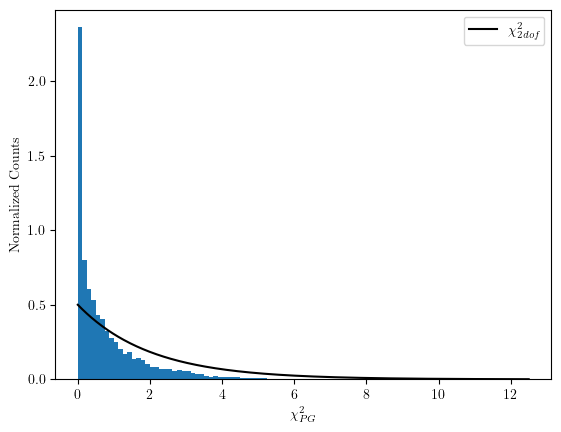

In [86]:
plt.hist(PG_null_exact, bins = 100, density = True)
x = np.linspace(0, max(PG_null_exact), 500)
y = stats.chi2.pdf(x, df=2)
plt.plot(x,y, color = 'black', label = '$\chi^2_{2 dof}$')
plt.xlabel("$\chi^2_{PG}$")
plt.legend()
plt.ylabel("Normalized Counts")
plt.show()

In [32]:
log_p_vals_exact_freq = []
log_p_vals_exact_wilks = []

for data in tqdm(data_arr):
    data1=data[:5]
    data2 = data[5:]
    chi2_1 = np.array([
    f.compute_delta_chi2(data1, 10**theta[0], 10**theta[1])
    for theta in THETAS
    ])
    chi2_2 = np.array([
    f.compute_delta_chi2(data2, 10**theta[0], 10**theta[1])
    for theta in THETAS
    ])
    
    chi2_1_min = np.min(chi2_1)
    chi2_2_min = np.min(chi2_2)
    joint_chi2 = chi2_1 + chi2_2
    joint_chi2_min = np.min(joint_chi2)
    PG = joint_chi2_min - chi2_1_min - chi2_2_min
    p_val =np.mean(PG_null_exact>PG)
    log_p_vals_exact_freq.append(-np.log(p_val))
    p_val = stats.chi2.sf(PG, df=2)
    log_p_vals_exact_wilks.append(-np.log(p_val))
    

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:11<00:00,  1.40it/s]


# PG Tension using SBI

To evaluate tension using SBI, we find $\chi^2_{PG}$ using a difference in $\Delta \chi^2$s:

$$\chi^2_{PG} = \chi^2_{glob,min} - \chi^2_{A,min} - \chi^2_{B,min}$$
$$= \chi^2_{glob,min} - \chi^2_{A,min} - \chi^2_{B,min} - (\chi^2_{glob,0} - \chi^2_{A,0} - \chi^2_{B,0})$$
$$=\Delta \chi^2_{glob} - \Delta \chi^2_{A} - \Delta \chi^2_B.$$
We have access to log-likelihood ratios $\hat r(x, \theta_1, \theta_2)$ via our network, thus we can construct an SBI-analogue of the PG statistic, $\hat T_{PG}$:
$$T(\theta) = -2 \hat r(x, \theta_0, \hat \theta)_{comb} - (-2 \hat r(x, \theta_0, \hat \theta)_A) - (-2 \hat r(x, \theta_0, \hat \theta)_B)$$

and we calculate this significance of $T_{PG}$ for tense pseudo-experiments empirically, using a distribution of $T_{PG}$ evaluated on null pseudo-experiments.

In [16]:
#loading in model trained on combined data
model_comb = load_model('models/model_comb.keras')
pre_sigmoid_model_comb= load_model("models/pre_sig_model_comb.keras", compile=False)
optimizer = tensorflow.keras.optimizers.Adam(learning_rate=1e-4)
pre_sigmoid_model_comb.compile(optimizer=optimizer, loss='binary_crossentropy',metrics=[metrics.AUC()])
scaler_comb = joblib.load("models/scaler_comb.joblib")

#same model for experiment A and B
model = load_model('models/model.keras')
pre_sigmoid_model= load_model("models/pre_sig_model.keras", compile=False)
optimizer = tensorflow.keras.optimizers.Adam(learning_rate=1e-4)
pre_sigmoid_model.compile(optimizer=optimizer, loss='binary_crossentropy',metrics=[metrics.AUC()])
scaler = joblib.load("models/scaler.joblib")

In [21]:
#picking a null parameter point to evaluate the log-likelihood ratio with
th_null = np.array([-3.9,0.5])

In [9]:
#constructing null distribution of \hat r(x, \theta_0, \hat \theta)_{comb}
dllh_null_sbi = []
bfs_null = []
for x in tqdm(x_arr_null):
    llh,bfp = f.compute_dllh_estimate(th_null, x, pre_sigmoid_model_comb, scaler_comb, 300, GRIDSIZE)
    dllh_null_sbi.append(llh)
    bfs_null.append(bfp)
    
np.save("output/dllh_null_comb", np.array(dllh_null_sbi))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [26:51<00:00,  3.10it/s]


In [11]:
#constructing null distribution of \hat r(x, \theta_0, \hat \theta)_{A}
dllh_null_sbi1 = []
bfs_null1 = []
for x in tqdm(x_arr_null):
    llh,bfp = f.compute_dllh_estimate(th_null, x[:5], pre_sigmoid_model, scaler, 300, GRIDSIZE)
    dllh_null_sbi1.append(llh)
    bfs_null1.append(bfp)
    
np.save("output/dllh_null1", np.array(dllh_null_sbi1))

 76%|███████████████████████████████████████████████████████████████████▊                     | 3807/5000 [18:16<05:42,  3.48it/s]

In [12]:
#constructing null distribution of \hat r(x, \theta_0, \hat \theta)_{B}
dllh_null_sbi2 = []
bfs_null2 = []
for x in tqdm(x_arr_null):
    llh,bfp = f.compute_dllh_estimate(th_null, x[5:], pre_sigmoid_model, scaler, 300, GRIDSIZE)
    dllh_null_sbi2.append(llh)
    bfs_null2.append(bfp)

np.save("output/dllh_null2", np.array(dllh_null_sbi2))

In [87]:
dllh_null_sbi2 = np.load("output/dllh_null2.npy")
dllh_null_sbi1 = np.load("output/dllh_null1.npy")
dllh_null_sbi = np.load("output/dllh_null_comb.npy")

In [137]:
dllh_PG_null =np.array(dllh_null_sbi) - np.array(dllh_null_sbi1) - np.array(dllh_null_sbi2)

#evaluating tense realizations using SBI
log_p_vals = []
for data in tqdm(data_arr):
    dllh1, bfp = f.compute_dllh_estimate(th_null, data[:5], pre_sigmoid_model, scaler, 500, GRIDSIZE)
    dllh2, bfp = f.compute_dllh_estimate(th_null, data[5:], pre_sigmoid_model, scaler, 500, GRIDSIZE)
    dllh_comb, bfp = f.compute_dllh_estimate(th_null, data, pre_sigmoid_model_comb, scaler_comb, 500, GRIDSIZE)
    dllh_PG = dllh_comb - dllh1 - dllh2
    p_val = np.mean(dllh_PG_null>dllh_PG)
    log_p_vals.append(-np.log(p_val))

100%|██████████████████████████████████████████████████| 100/100 [02:07<00:00,  1.27s/it]


In [185]:
np.save("output/log_p_vals", log_p_vals)
np.save("output/log_p_vals_exact_freq", log_p_vals_exact_freq)

Below we plot the analytic ("exact") significance of the PG tension against the SBI-computed significance of the PG tension, where both significances are computed empirically. 

m = 1.014 ± 0.113
b = -0.237 ± 0.050


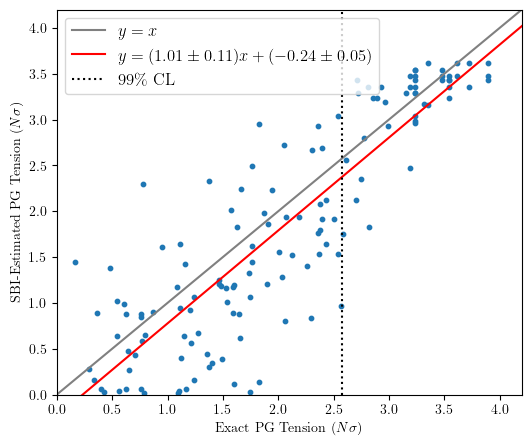

In [160]:
from scipy.stats import norm
fig, axs = plt.subplots(1,1,figsize=(6,5))
exact_sig = norm.isf(np.exp(-np.array(log_p_vals_exact_freq))/2)
sbi_sig = norm.isf(np.exp(-np.array(log_p_vals))/2)
plt.scatter(exact_sig,sbi_sig, s = 10)
plt.plot(np.linspace(0,5,10), np.linspace(0,5,10), color = 'grey', label = '$y=x$')
plt.legend()
plt.xlabel("Exact PG Tension ($N \sigma$)")
plt.ylabel("SBI-Estimated PG Tension ($N \sigma$)")

mask = np.isfinite(exact_sig) & np.isfinite(sbi_sig)
log_p_vals_exact_freq_arr = np.array(exact_sig)
log_p_vals_arr = np.array(sbi_sig)
(coefs, cov) = np.polyfit(log_p_vals_exact_freq_arr[mask], log_p_vals_arr[mask], 1, cov=True)
m,b = coefs
sigma_b = np.sqrt(cov[0, 0])
sigma_m = np.sqrt(cov[1, 1])
x = np.linspace(0,4.2,10)
print(f"m = {m:.3f} ± {sigma_m:.3f}")
print(f"b = {b:.3f} ± {sigma_b:.3f}")

plt.plot(
    x, m*x + b,
    color='red',
    label=f'$y=({m:.2f}\pm{sigma_m:.2f})x + ({b:.2f}\pm{sigma_b:.2f})$'
)
y_err = np.sqrt(
    x_fit**2 * cov[0, 0]
    + cov[1, 1]   + 2*x_fit*cov[0, 1]
  
)

plt.axvline(2.576, color = 'black', linestyle = 'dotted', label = '99\% CL')
plt.legend(fontsize=12)
plt.xlim(0,4.2)
plt.ylim(0,4.2)
plt.savefig(f"tension_comparison.png", dpi=300)

Below we plot the analytic ("exact") significance of the PG tension against the SBI-computed significance of the PG tension, where the exact significance is computed assuming a Wilks' distribution with 2 degrees of freedom. Note the "saturation effect" that occurs for the SBI-computed signifiances when the significance of very signal-like realizations is limited by the number of trials evaluated, which we call the "empirical limit". 

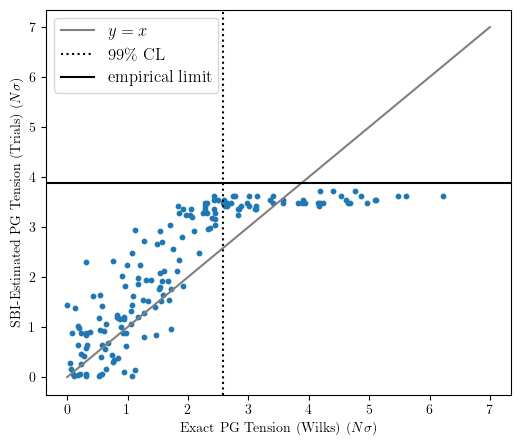

In [170]:
from scipy.stats import norm
fig, axs = plt.subplots(1,1,figsize=(6,5))
exact_sig = norm.isf(np.exp(-np.array(log_p_vals_exact_wilks))/2)
sbi_sig = norm.isf(np.exp(-np.array(log_p_vals))/2)
plt.scatter(exact_sig,sbi_sig, s = 10)
plt.plot(np.linspace(0,7,10), np.linspace(0,7,10), color = 'grey', label = '$y=x$')
plt.legend()
plt.xlabel("Exact PG Tension (Wilks) ($N \sigma$)")
plt.ylabel("SBI-Estimated PG Tension (Trials) ($N \sigma$)")

plt.axvline(2.576, color = 'black', linestyle = 'dotted', label = '99\% CL')

plt.axhline(norm.isf(1/20000),color = 'black', label = 'empirical limit')
plt.legend(fontsize=12)